In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("../data/FRB_H15.csv").dropna()
df.tail()

,Series Description,"Market yield on U.S. Treasury securities at 1-month constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 3-month constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 6-month constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 1-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 2-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 3-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 5-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 7-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 10-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 20-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 30-year constant maturity, quoted on investment basis"
16788,2026-05-08,3.71,3.69,3.74,3.75,3.90,3.92,4.02,4.19,4.38,4.93,4.95
16789,2026-05-11,3.71,3.70,3.77,3.79,3.95,3.96,4.07,4.24,4.42,4.97,4.98
16790,2026-05-12,3.71,3.70,3.77,3.80,4.00,4.01,4.12,4.29,4.46,5.02,5.03
16791,2026-05-13,3.71,3.69,3.77,3.79,3.98,4.00,4.12,4.28,4.46,5.03,5.03
16792,2026-05-14,3.72,3.69,3.76,3.79,4.00,4.04,4.13,4.29,4.47,5.01,5.02


In [4]:
from hmmlearn.hmm import GaussianHMM

In [5]:
model = GaussianHMM(n_components=3, covariance_type='full', n_iter=100)

X = df.iloc[1:].drop(columns=["Series Description"])
model.fit(X)

,n_components,3
,covariance_type,'full'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,None


In [6]:
states = model.predict(X)

In [7]:
# transition matrix
model.transmat_

array([[9.96753825e-01, 8.44842024e-04, 2.40133338e-03],
       [4.35882793e-04, 9.98737401e-01, 8.26716356e-04],
       [7.92177923e-04, 7.92824217e-04, 9.98414998e-01]])

In [8]:
import matplotlib.pyplot as plt

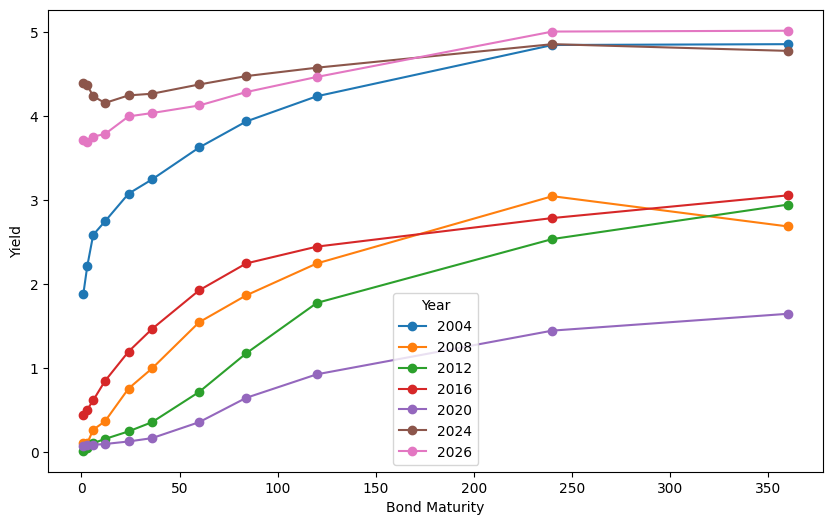

In [ ]:
X_plt = [1, 3, 6, 12, 24, 36, 60, 84, 120, 240, 360]
years = list(range(2000, 2027, 4))
if 2026 not in years:
    years.append(2026)

plot_df = df.copy()
plot_df["Date"] = pd.to_datetime(plot_df["Series Description"])

plt.figure(figsize=(10, 6))
for year in years:
    year_df = plot_df[plot_df["Date"].dt.year == year]
    if year_df.empty:
        continue

    row = year_df.iloc[-1]
    y_plt = [row.iloc[i] for i in range(1, 12)]
    plt.plot(X_plt, y_plt, marker="o", label=str(year))

plt.xlabel("Bond Maturity")
plt.ylabel("Yield")
plt.legend(title="Year", )
plt.show()